## Mapping plot / Figure 1

All files on farm in `/home/ctbrown/scratch3/2025-workflow-core99/`

In [6]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

# outputs from running `do_mapping`:
BASE_OUTPUTS=BASE+'/outputs.mapping/bams.cds.rand'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [54]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import scipy

import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

In [40]:
NAMES = [ x.strip() for x in open(BASE+'/inputs.mapping/names-plus.list') ]
print(f'loaded {len(NAMES)} species names')

SPECIAL = [ x.strip() for x in open(BASE+'/inputs.mapping/names.list') ]
print(f'loaded {len(NAMES)} special species names')

NAMES.sort()
NAMES

loaded 26 species names
loaded 26 special species names


['s__Bariatricus sp004560705',
 's__Bifidobacterium thermacidophilum',
 's__Blautia_A sp945872375',
 's__CAG-269 sp014846485',
 's__CAG-465 sp000433755',
 's__CAG-873 sp016302215',
 's__Cryptobacteroides sp900546925',
 's__Fimisoma sp002320005',
 's__Gemmiger qucibialis',
 's__Holdemanella porci',
 's__JAFBIX01 sp021531895',
 's__JALFVM01 sp022787145',
 's__Lactobacillus amylovorus',
 's__Mogibacterium_A kristiansenii',
 's__Phascolarctobacterium_A succinatutens',
 's__Phascolarctobacterium_A succinatutens_B',
 's__Prevotella sp000434975',
 's__Prevotella sp002251295',
 's__Roseburia inulinivorans',
 's__Ruminococcoides sp902766885',
 's__Ruminococcus_C sp000433635',
 's__SIG351 sp945918795',
 's__Sodaliphilus sp004557565',
 's__UBA2868 sp004552595',
 's__UMGS1225 sp034086705',
 's__Ventricola sp017937505']

In [41]:
XX_NAMES=(             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',)

In [42]:
dflist = []

for name in NAMES:
    rand_df = pl.read_csv(BASE_OUTPUTS + f'/{name}.readstats.csv').with_columns(
        pl.lit(name).alias("species"),
        pl.lit("100 randomly chosen metagenomes").alias("type"),
    )
    assert len(rand_df) == 100, "expect 100 random metagenomes, dude"

    combo_df = rand_df
    combo_df = combo_df.with_columns(
        (pl.col("count") / 1e3).alias("count_k"),
        (pl.col("species").str.slice(3)).alias("name"),
    )
    dflist.append(combo_df)

mapping_df = pl.concat(dflist)
mapping_df

,metag,count,species,type,count_k,name
i64,str,i64,str,str,f64,str
0,"""ERR3211766""",221186,"""s__Bariatricus sp004560705""","""100 randomly chosen metagenome…",221.186,"""Bariatricus sp004560705"""
1,"""SRR11126273""",121773,"""s__Bariatricus sp004560705""","""100 randomly chosen metagenome…",121.773,"""Bariatricus sp004560705"""
2,"""SRR8960968""",939776,"""s__Bariatricus sp004560705""","""100 randomly chosen metagenome…",939.776,"""Bariatricus sp004560705"""
3,"""SRR14369136""",636067,"""s__Bariatricus sp004560705""","""100 randomly chosen metagenome…",636.067,"""Bariatricus sp004560705"""
4,"""SRR17241596""",2122694,"""s__Bariatricus sp004560705""","""100 randomly chosen metagenome…",2122.694,"""Bariatricus sp004560705"""
…,…,…,…,…,…,…
95,"""ERR3211783""",9787,"""s__Ventricola sp017937505""","""100 randomly chosen metagenome…",9.787,"""Ventricola sp017937505"""
96,"""SRR14812369""",20378,"""s__Ventricola sp017937505""","""100 randomly chosen metagenome…",20.378,"""Ventricola sp017937505"""
97,"""SRR8655115""",38923,"""s__Ventricola sp017937505""","""100 randomly chosen metagenome…",38.923,"""Ventricola sp017937505"""


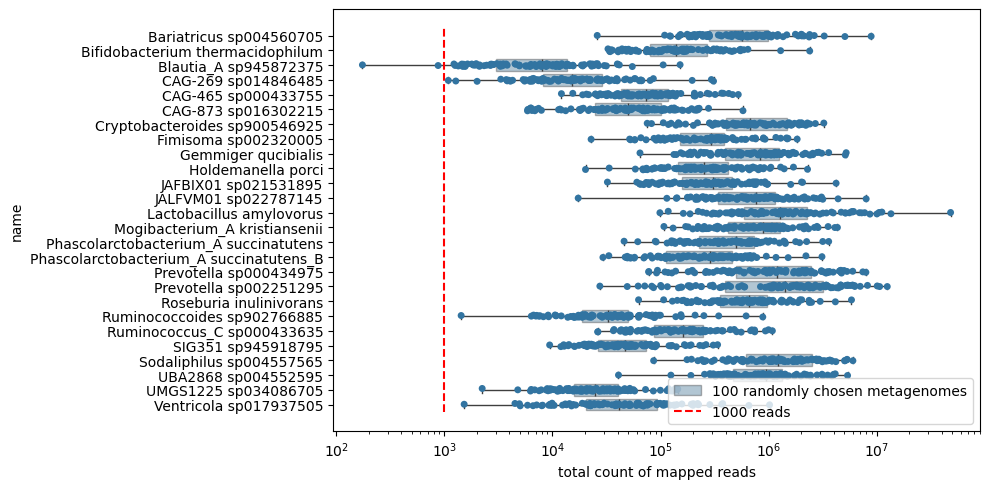

In [43]:
# Source - https://stackoverflow.com/a
# Posted by JohanC, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-03, License - CC BY-SA 4.0

hue_order=["100 randomly chosen metagenomes"]
palette={ hue_order[0]: (0.19460784313725488, 0.45343137254901944, 0.632843137254902),
          }
#palette = None

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=mapping_df, y="name", x="count", hue="type",
                 hue_order=hue_order, palette=palette, boxprops={'alpha': 0.4}, whis=(0, 100))
sns.stripplot(data=mapping_df, y="name", x="count", hue="type", 
              hue_order=hue_order, palette=palette, dodge=True, ax=ax, legend=False)
handles, labels = ax.get_legend_handles_labels()
ax.set_xlabel("total count of mapped reads")

# print out default bar colors if we want:
#bar_colors = set([bar.get_facecolor() for bar in ax.patches])
#print(f"Colors of the bars: {bar_colors}")

# set ylim to provide room for legend
ylim = ax.get_ylim()
#ax.set_ylim(18.5, -0.5)
#print('ylim:', ylim)

ax.plot([1000, 1000], ylim, '--', color='red', label="1000 reads")
ax.legend(loc='lower right')
ax.set_xscale('log')

plt.tight_layout()

plt.savefig(FIG_OUT + '/figure1-mapping-cds.png')

### CAPTION: Figure 1: Metagenome read mapping confirms presence for 18 species.

Counts for metagenome reads mapped to 18 bacterial pangenomes, for two different subsets of 3,216 Illumina paired-end pig gut metagenomes. The orange points are read mapping counts for reads from the 35 distinct metagenomes that contain the five lowest k-mer detection scores for each of the 18 pangenomes. The blue points are read mapping counts for 100 metagenomes chosen to represent datasets generated from distinct individuals across the full range of countries of origin. The boxplots contain the middle 50% of the data, with the whiskers covering the full range of points. The red dashed line is set at 10,000 read counts to visually indicate the lower bound on read mapping counts for the lowest-mapped pangenome (11,157 reads, for *s__Holdemanella porci*). The X axis shows absolute read counts in units of 1000 in log scale.

In [44]:
manysearch_df = pl.read_parquet('../outputs.mapping/cds3/manysearch.3216.parquet').with_columns(
    pl.col("query_name").alias("species"),
    pl.col("match_name").alias("metag"),
    (pl.col("intersect_hashes") * pl.col("scaled") / pl.col("containment")).alias("sketch_size"),
)


In [45]:
manysearch_df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species,metag,sketch_size
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64
"""s__Prevotella sp002251295""","""11c2f06bb0ba002567a1bdc2a57126…","""SRR11126108""",0.102068,528,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.001608,0.102068,1.738636,1.0,1.099183,0.897025,0.736655,0.81684,0.897025,918,906559,"""s__Prevotella sp002251295""","""SRR11126108""",5.173e6
"""s__UMGS1225 sp034086705""","""32711230ebb0936ab57ed263368289…","""SRR11126108""",0.016775,18,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000055,0.016775,1.222222,1.0,0.41574,0.823115,0.627176,0.725146,0.823115,22,906559,"""s__UMGS1225 sp034086705""","""SRR11126108""",1.073e6
"""s__Mogibacterium_A kristiansen…","""a6063c0962c975db514497f271511e…","""SRR11126108""",0.101576,303,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000928,0.101576,2.894389,2.0,1.912803,0.896818,0.717428,0.807123,0.896818,877,906559,"""s__Mogibacterium_A kristiansen…","""SRR11126108""",2.983e6
"""s__JAFBIX01 sp021531895""","""2902fdae1da9e7a10d826eac534864…","""SRR11126108""",0.073482,207,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000634,0.073482,1.294686,1.0,0.719044,0.883098,0.704529,0.793813,0.883098,268,906559,"""s__JAFBIX01 sp021531895""","""SRR11126108""",2.817e6
"""s__Phascolarctobacterium_A suc…","""b8c6bbf9560cfc087687eb69f00b1c…","""SRR11126108""",0.171033,235,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000724,0.171033,3.370213,2.0,2.797257,0.919348,0.708798,0.814073,0.919348,792,906559,"""s__Phascolarctobacterium_A suc…","""SRR11126108""",1.374e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Roseburia inulinivorans""","""f2654d4c2e0a7a74479c509794d10f…","""ERR8314759""",0.037142,261,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000095,0.037142,3.56705,1.0,10.879359,0.854867,0.643489,0.749178,0.854867,931,9259617,"""s__Roseburia inulinivorans""","""ERR8314759""",7.027e6
"""s__CAG-269 sp014846485""","""078c4569f257f75356832c47c16808…","""ERR8314759""",0.009174,4,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000001,0.009174,1.5,1.5,0.5,0.799797,0.527391,0.663594,0.799797,6,9259617,"""s__CAG-269 sp014846485""","""ERR8314759""",436000.0
"""s__Phascolarctobacterium_A suc…","""8c3d1fa61d73093ded0c14d4577909…","""ERR8314759""",0.010504,45,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000016,0.010504,1.711111,1.0,1.360102,0.804969,0.591817,0.698393,0.804969,77,9259617,"""s__Phascolarctobacterium_A suc…","""ERR8314759""",4.284e6


In [46]:
join_df = mapping_df.join(manysearch_df, on=['species', 'metag'], how='inner')
join_df = join_df.with_columns(
    (pl.col("count") / pl.col("sketch_size") * 100).alias("cov")
)

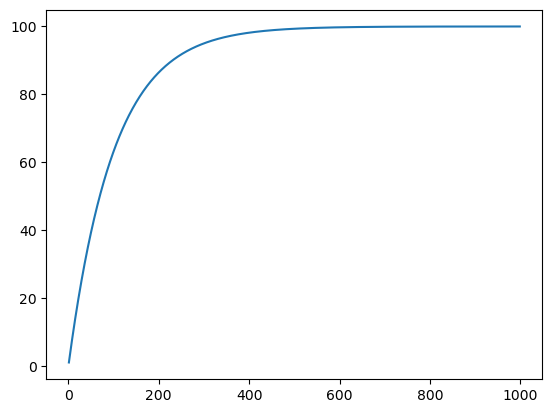

In [70]:
import math
def coverage_curve(x, c, e):
    return c*(1 - np.exp(-e*x))
x = np.arange(1, 1000)
y = [ coverage_curve(xx, 100, .01) for xx in x ]
plt.plot(x, y)



s__Bariatricus sp004560705
s__Bariatricus sp004560705 (1200000, 10.0)
s__Bariatricus sp004560705 [5.70808081e+05 1.00000000e+01]


/tmp/ipykernel_3852717/1703463668.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params, cv = scipy.optimize.curve_fit(coverage_curve, xs, ys, p0)


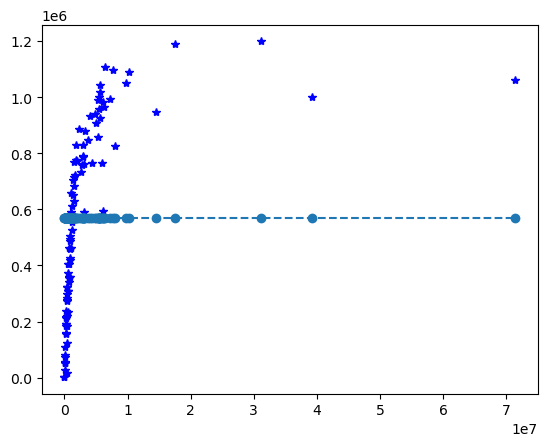

In [81]:
print(NAMES[0])
foo_df = join_df.filter(pl.col("species") == NAMES[0]).sort(by='n_weighted_found')

def do_fit(xx_df):
    name = xx_df['species'].unique().to_list()[0]    
    xs = xx_df['n_weighted_found']*1000
    ys = xx_df['intersect_hashes']*1000

    p0 = (max(ys), 10.0)
    params, cv = scipy.optimize.curve_fit(coverage_curve, xs, ys, p0)

    print(name, p0)
    print(name, params)

    yfit = coverage_curve(xs, *params)
    return yfit

yfit = do_fit(foo_df)
plt.plot(foo_df['n_weighted_found']*1000, foo_df['intersect_hashes']*1000, 'b*')
plt.plot(foo_df['n_weighted_found']*1000, yfit, 'o--')

s__Bariatricus sp004560705 (1200000, 0.1)
s__Bariatricus sp004560705 [9.60791337e+05 7.45251476e-04]


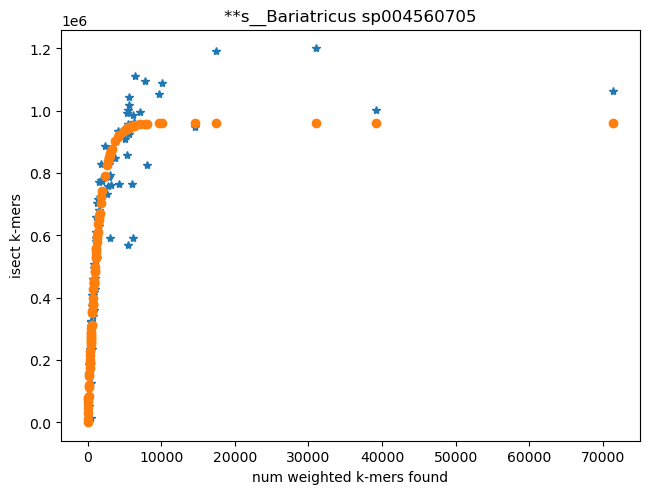

s__Bifidobacterium thermacidophilum (847000, 0.1)
s__Bifidobacterium thermacidophilum [8.08013093e+05 8.45321702e-04]


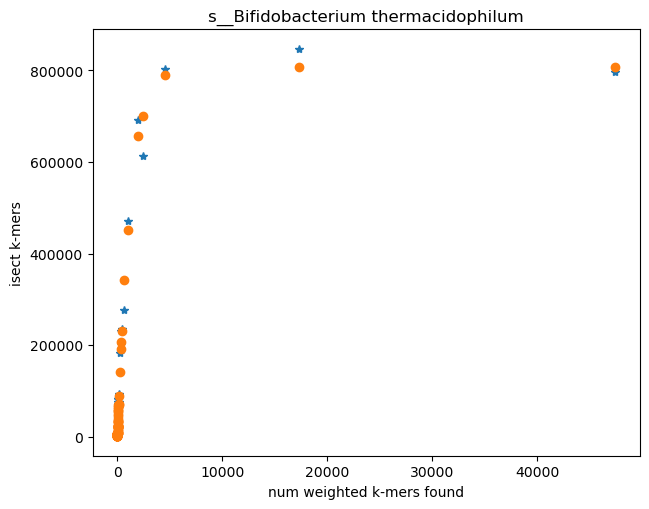

s__Blautia_A sp945872375 (375000, 0.1)
s__Blautia_A sp945872375 [5.65872521e+05 1.40022918e-03]


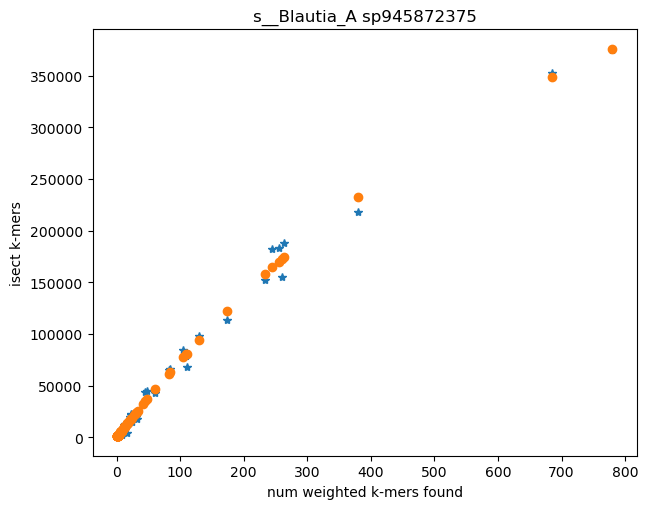

s__CAG-269 sp014846485 (255000, 0.1)
s__CAG-269 sp014846485 [2.43393588e+05 3.00737878e-03]


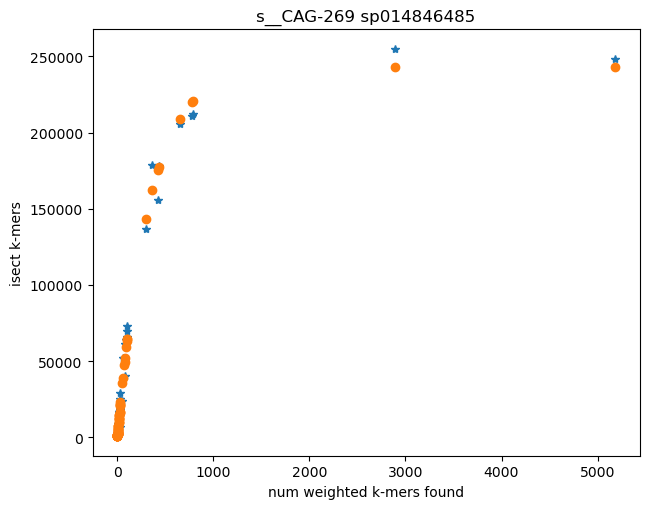

s__CAG-465 sp000433755 (159000, 0.1)
s__CAG-465 sp000433755 [4.74449331e+05 1.20099178e-03]


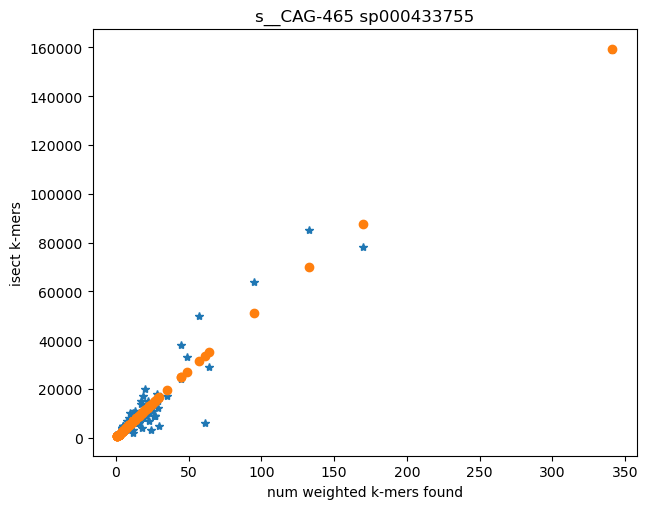

s__CAG-873 sp016302215 (1305000, 0.1)
s__CAG-873 sp016302215 [1.24135601e+06 6.45646511e-04]


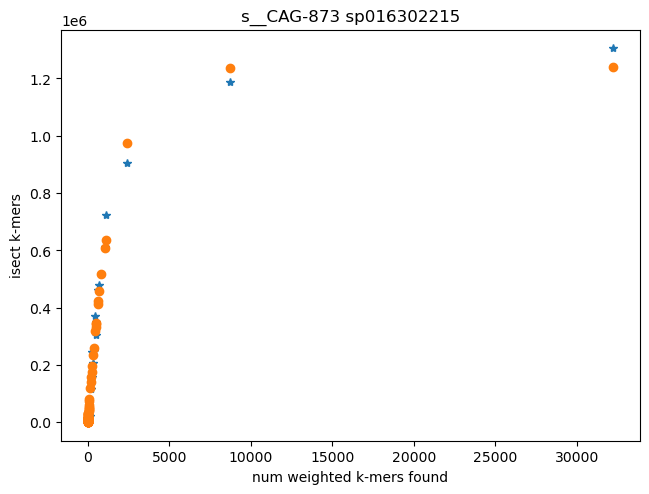

s__Cryptobacteroides sp900546925 (1470000, 0.1)
s__Cryptobacteroides sp900546925 [1.29353003e+06 5.10493568e-04]


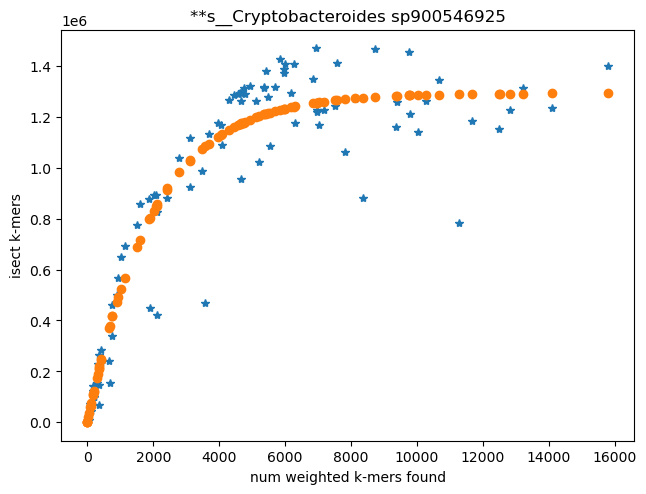

s__Fimisoma sp002320005 (991000, 0.1)
s__Fimisoma sp002320005 [8.76357148e+05 8.83344403e-04]


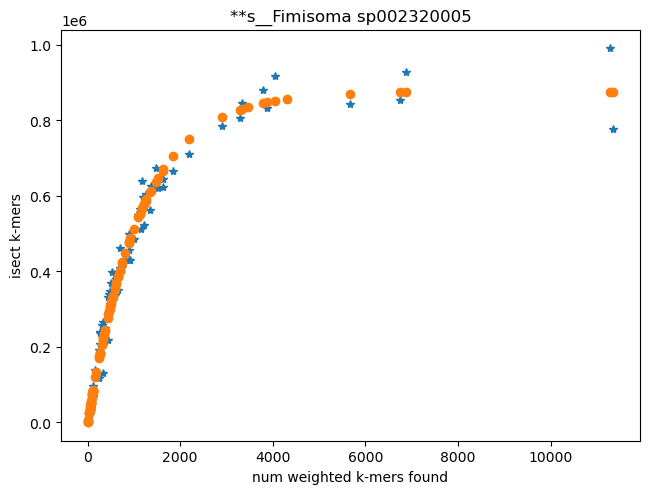

s__Gemmiger qucibialis (807000, 0.1)
s__Gemmiger qucibialis [5.60128482e+05 1.12116220e-03]


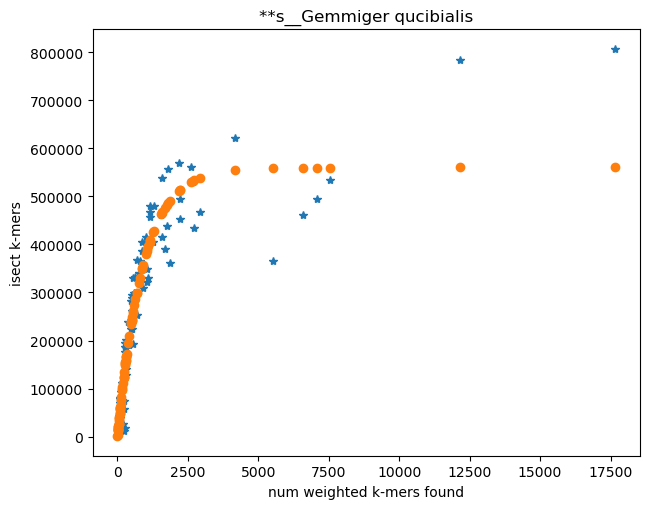

s__Holdemanella porci (296000, 0.1)
s__Holdemanella porci [2.22584555e+05 2.03404994e-03]


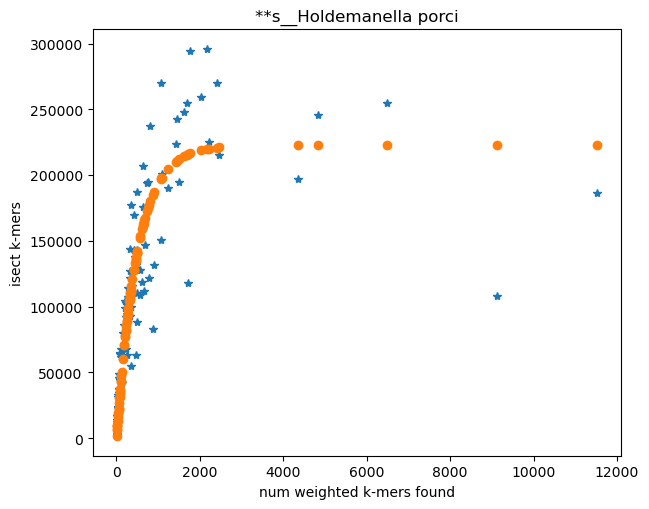

s__JAFBIX01 sp021531895 (1440000, 0.1)
s__JAFBIX01 sp021531895 [1.26694243e+06 5.36460381e-04]


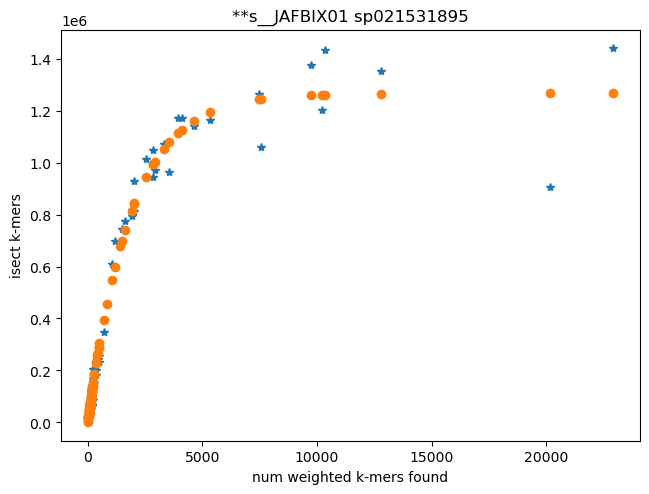

s__JALFVM01 sp022787145 (1238000, 0.1)
s__JALFVM01 sp022787145 [1.14126786e+06 4.71286659e-04]


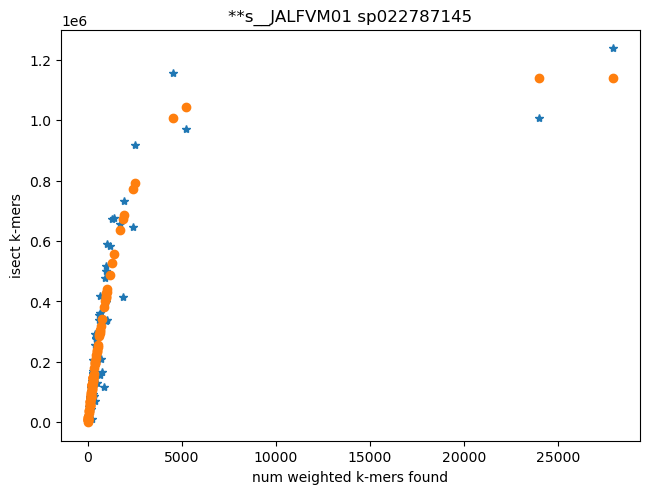

s__Lactobacillus amylovorus (806000, 0.1)
s__Lactobacillus amylovorus [3.73962800e+05 8.66969507e-04]


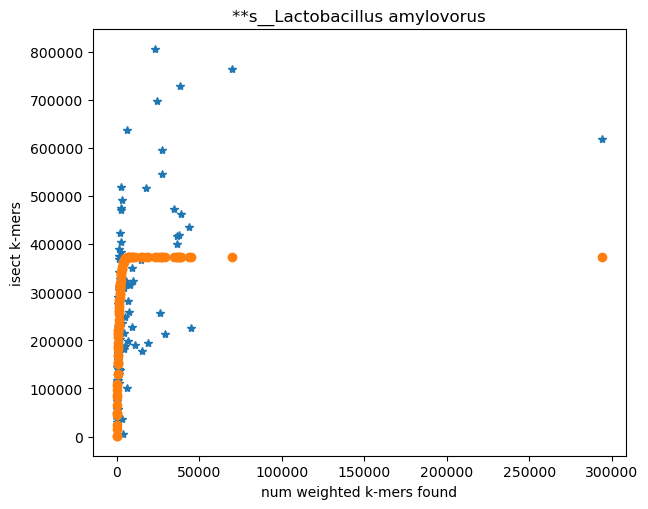

s__Mogibacterium_A kristiansenii (580000, 0.1)
s__Mogibacterium_A kristiansenii [4.41476926e+05 1.02767418e-03]


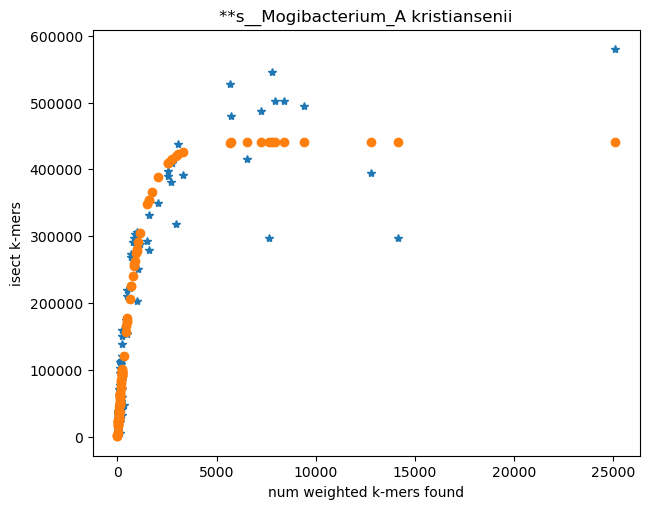

s__Phascolarctobacterium_A succinatutens (406000, 0.1)
s__Phascolarctobacterium_A succinatutens [3.13568852e+05 1.77497861e-03]


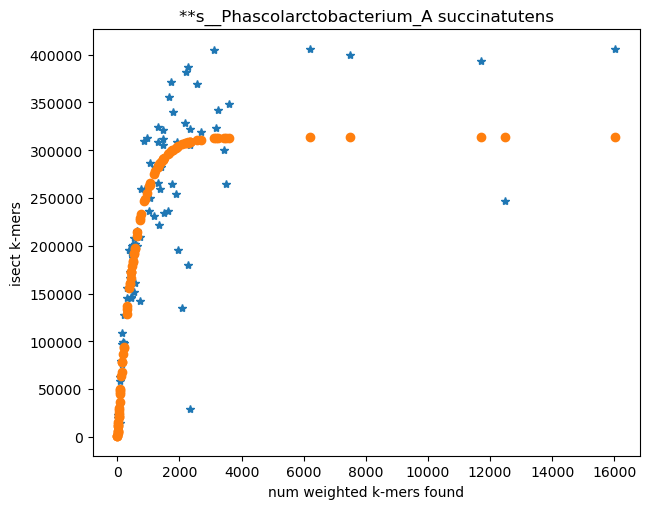

s__Phascolarctobacterium_A succinatutens_B (89000, 0.1)
s__Phascolarctobacterium_A succinatutens_B [8.85777678e+04 7.41031553e-03]


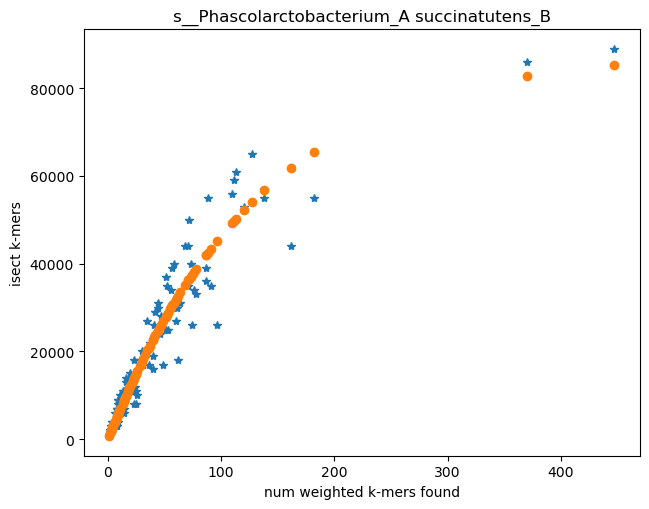

s__Prevotella sp000434975 (1724000, 0.1)
s__Prevotella sp000434975 [1.30675195e+06 2.83617703e-04]


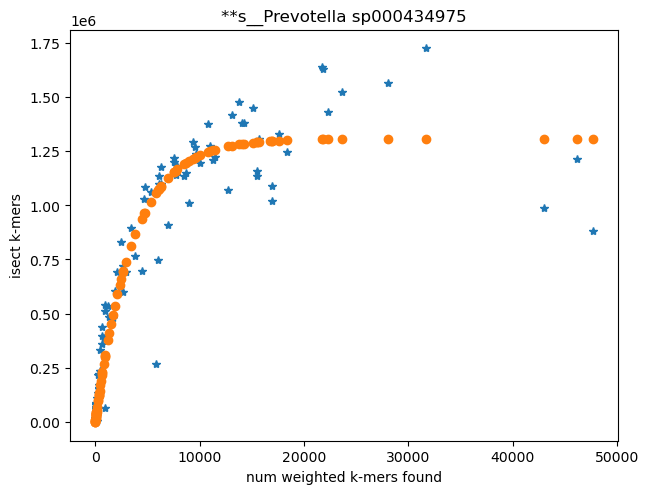

s__Prevotella sp002251295 (2033000, 0.1)
s__Prevotella sp002251295 [1.57383854e+06 3.27641523e-04]


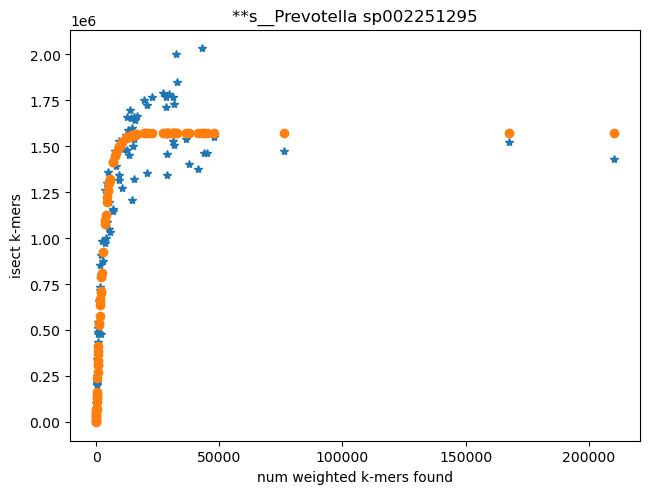

s__Roseburia inulinivorans (837000, 0.1)
s__Roseburia inulinivorans [8.32229225e+05 6.33873390e-04]


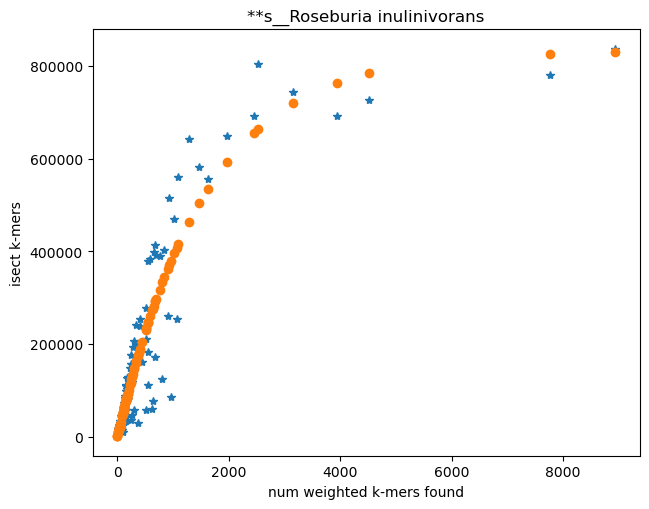

s__Ruminococcoides sp902766885 (609000, 0.1)
s__Ruminococcoides sp902766885 [6.01677050e+05 1.05728949e-03]


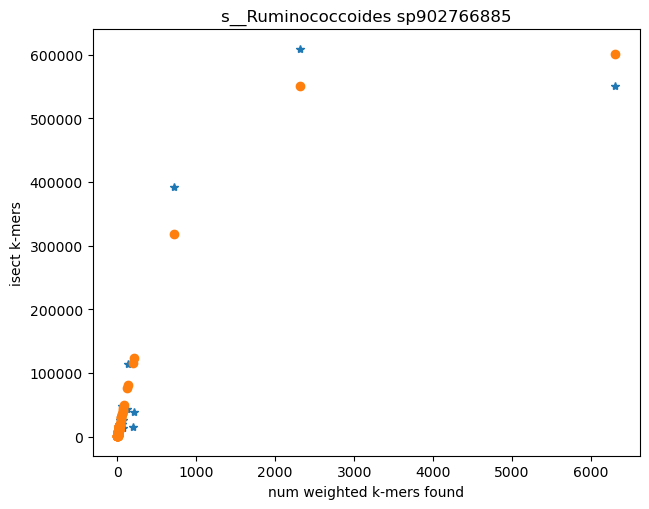

s__Ruminococcus_C sp000433635 (1367000, 0.1)
s__Ruminococcus_C sp000433635 [1.02088861e+06 6.76646993e-04]


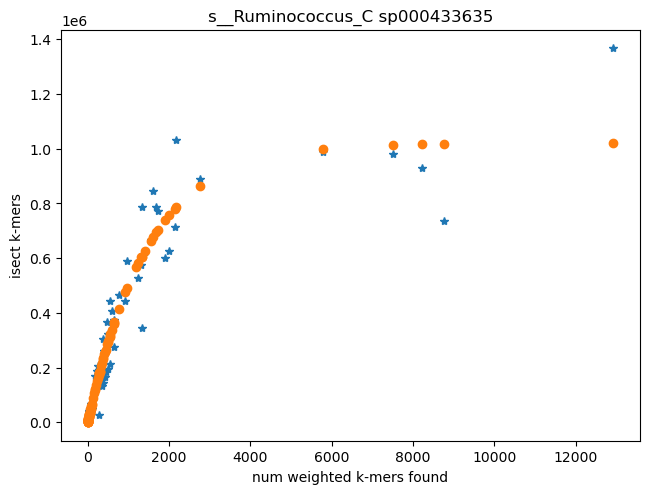

s__SIG351 sp945918795 (1191000, 0.1)
s__SIG351 sp945918795 [1.19247037e+06 6.35823200e-04]


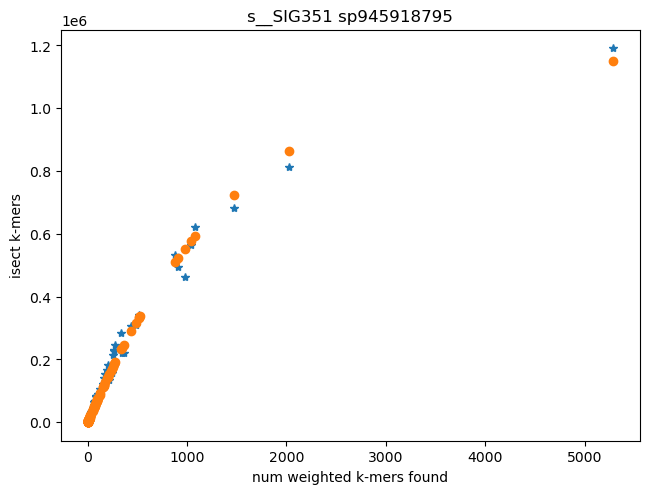

s__Sodaliphilus sp004557565 (3194000, 0.1)
s__Sodaliphilus sp004557565 [2.51158442e+06 1.49102595e-04]


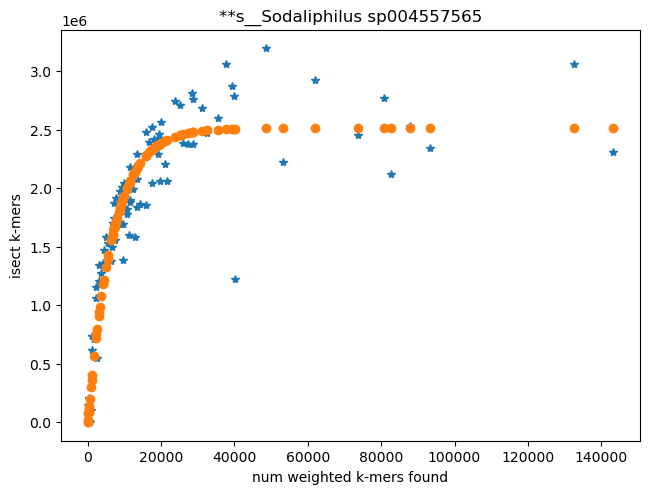

s__UBA2868 sp004552595 (2771000, 0.1)
s__UBA2868 sp004552595 [1.89953088e+06 1.95919409e-04]


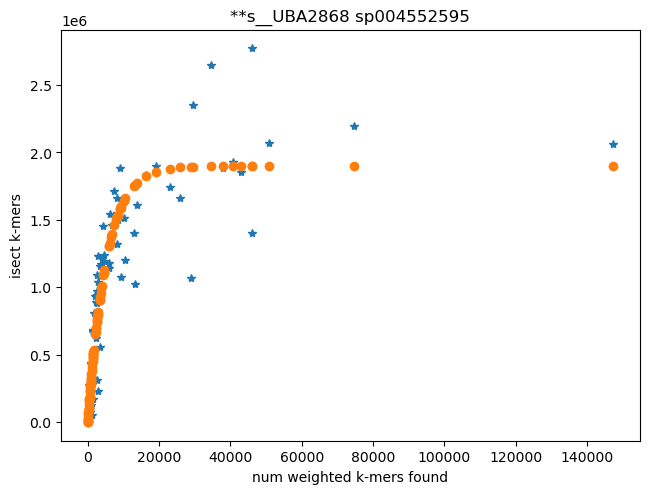

s__UMGS1225 sp034086705 (894000, 0.1)
s__UMGS1225 sp034086705 [9.17802523e+05 9.28627404e-04]


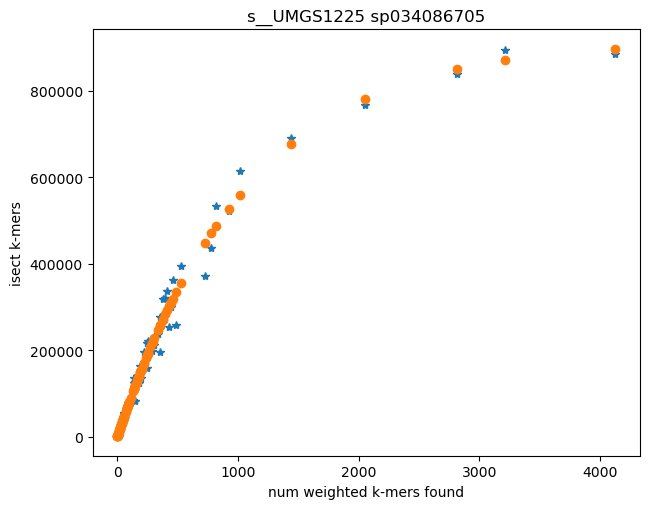

s__Ventricola sp017937505 (327000, 0.1)
s__Ventricola sp017937505 [3.31594070e+05 1.93078367e-03]


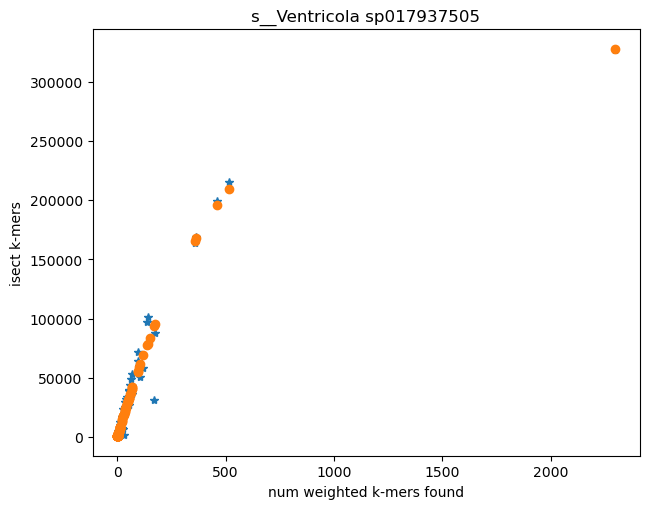

In [76]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)
    plt.plot(species_df['n_weighted_found'], species_df['intersect_hashes']*1000, '*')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlabel('num weighted k-mers found')
    plt.ylabel('isect k-mers')
    yfit = do_fit(species_df)
    plt.plot(species_df['n_weighted_found'], yfit, 'o')
    plt.show()

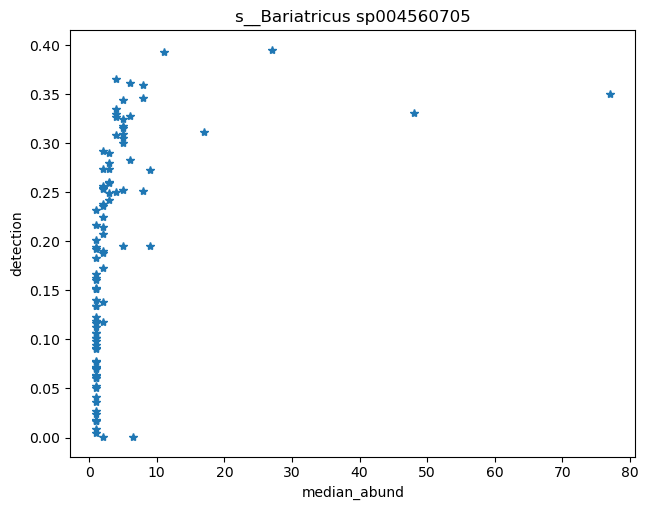

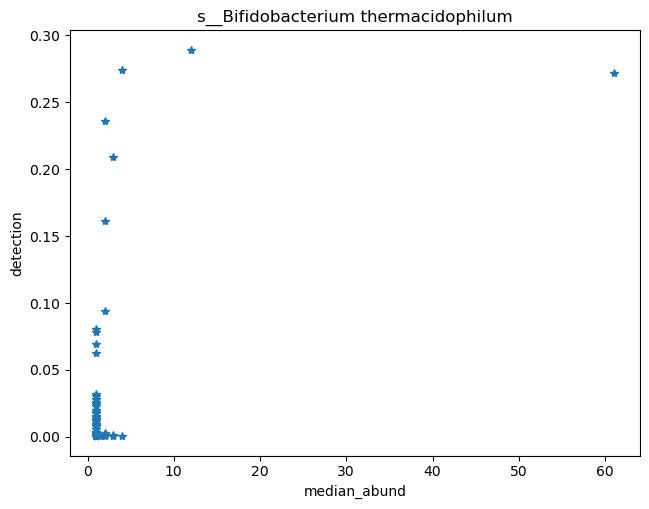

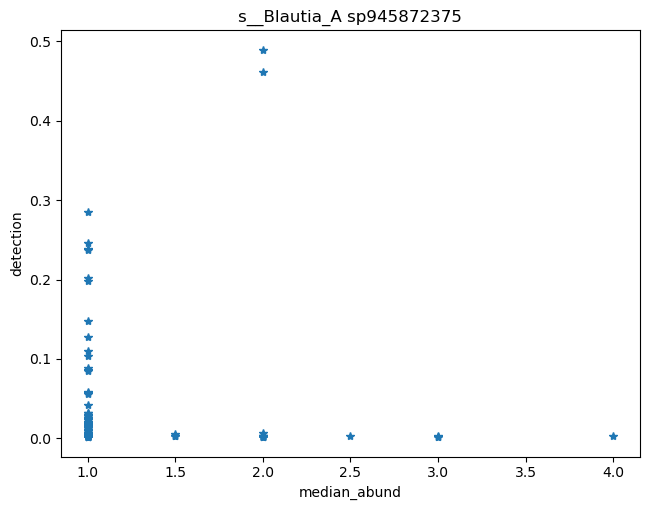

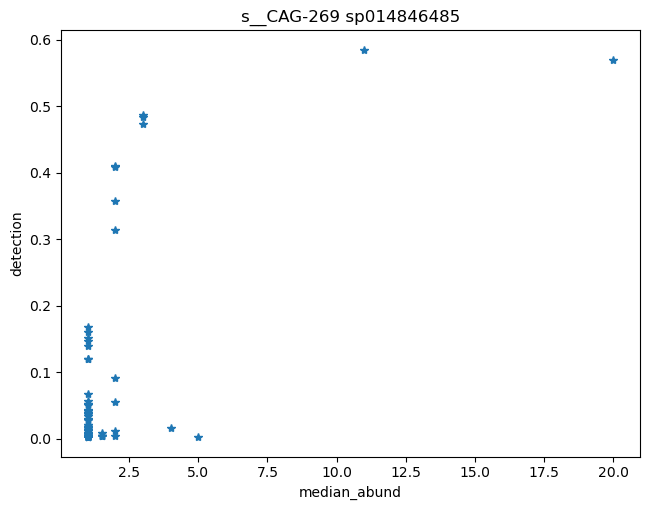

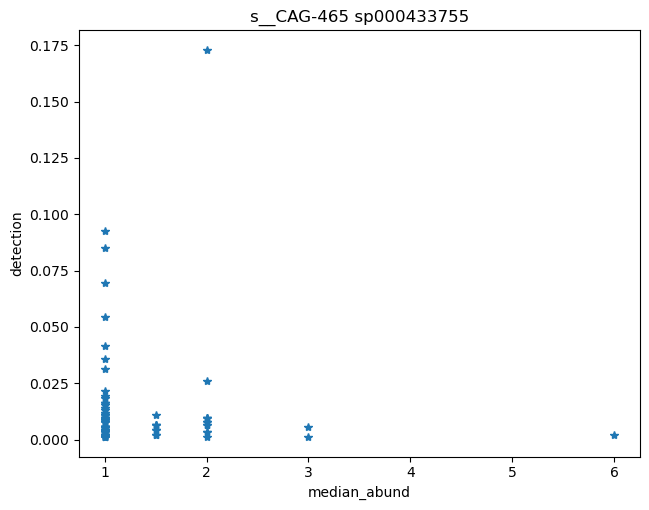

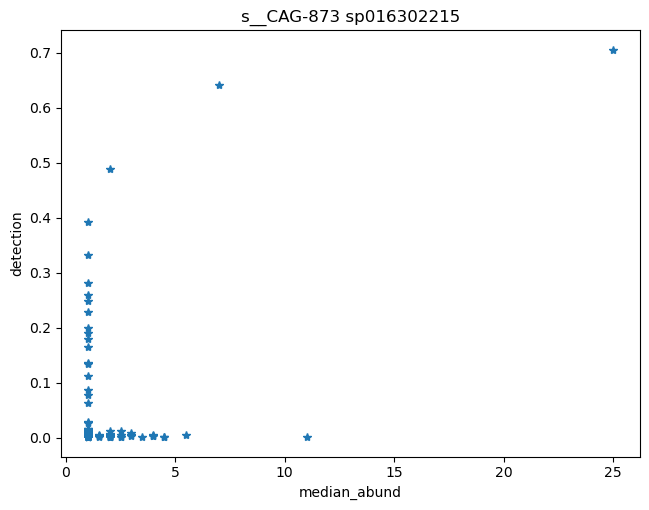

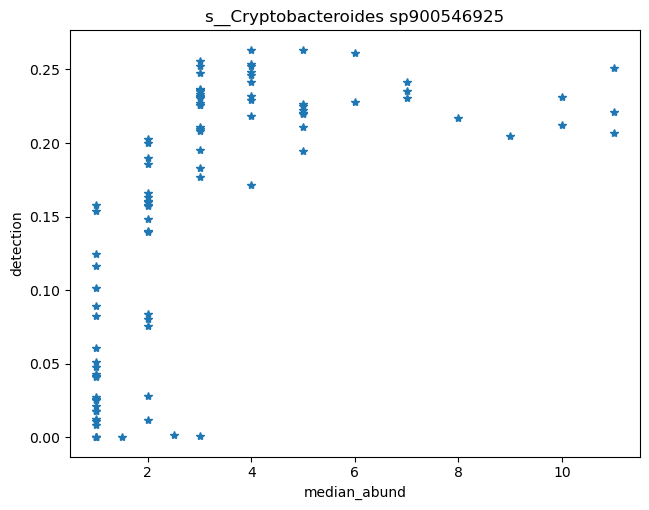

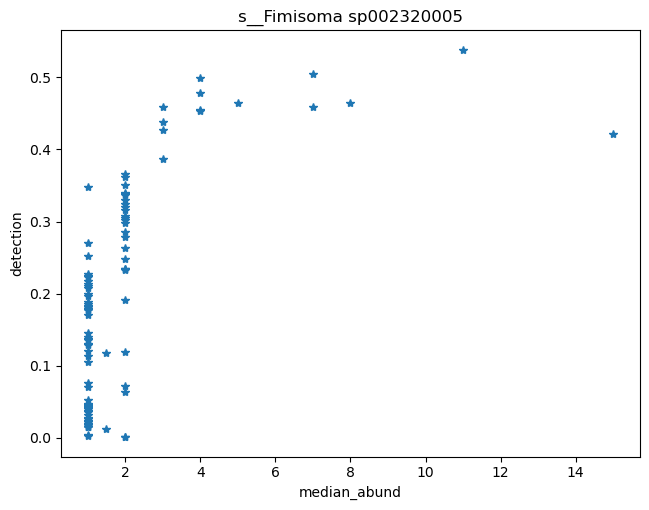

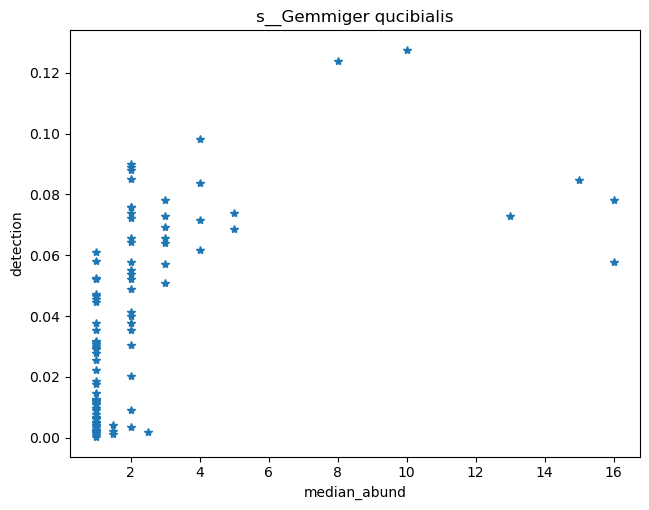

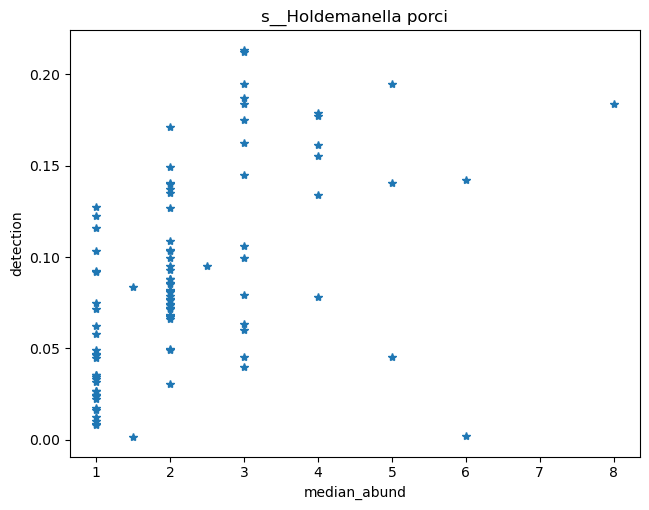

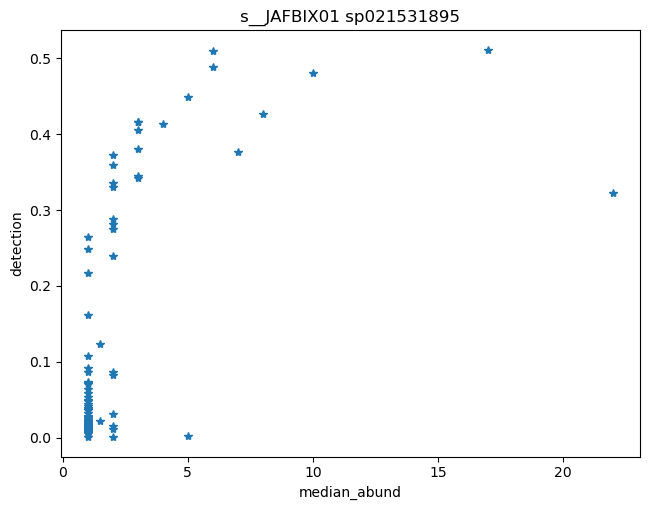

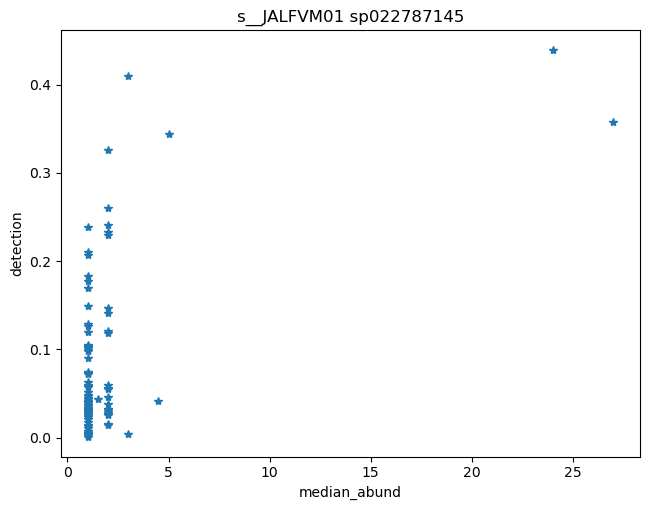

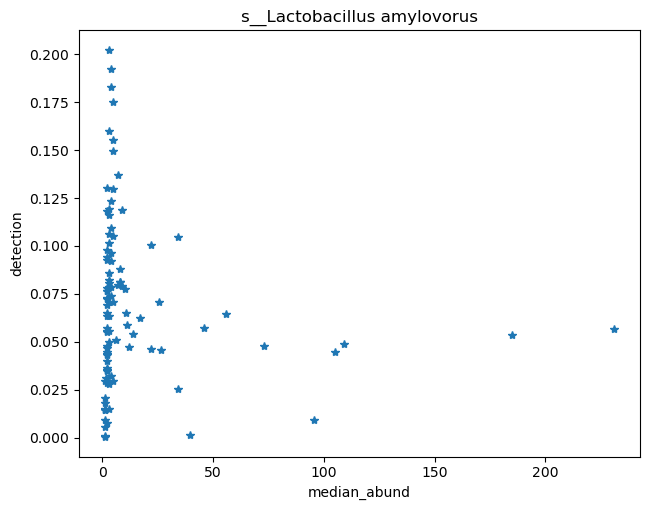

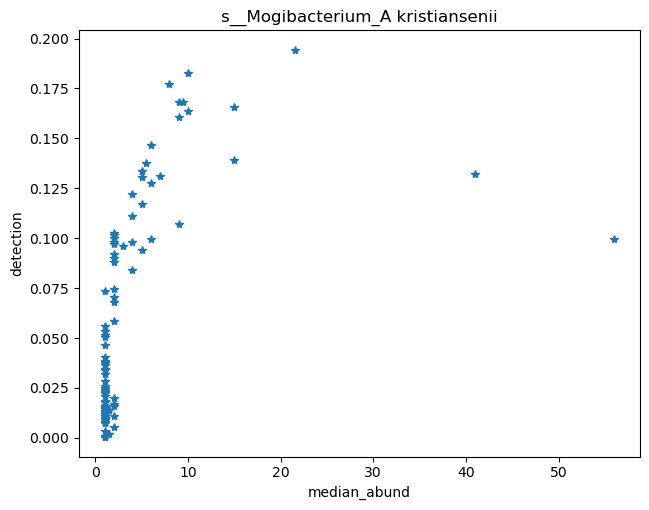

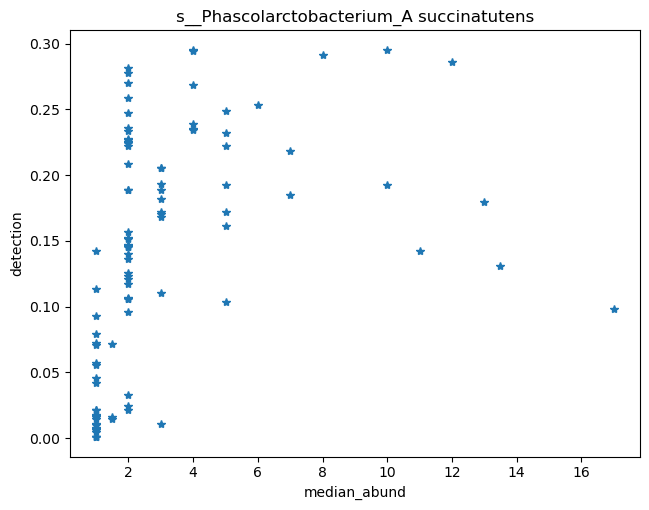

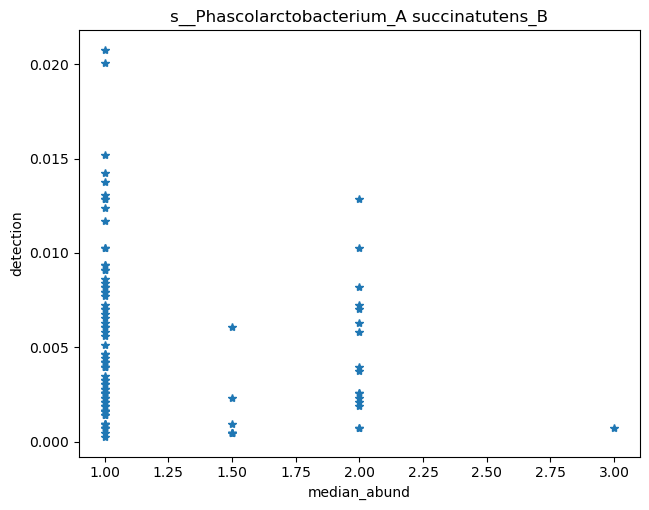

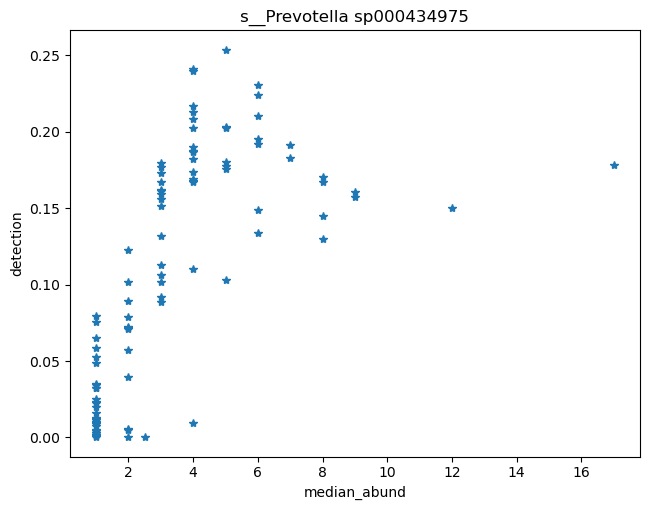

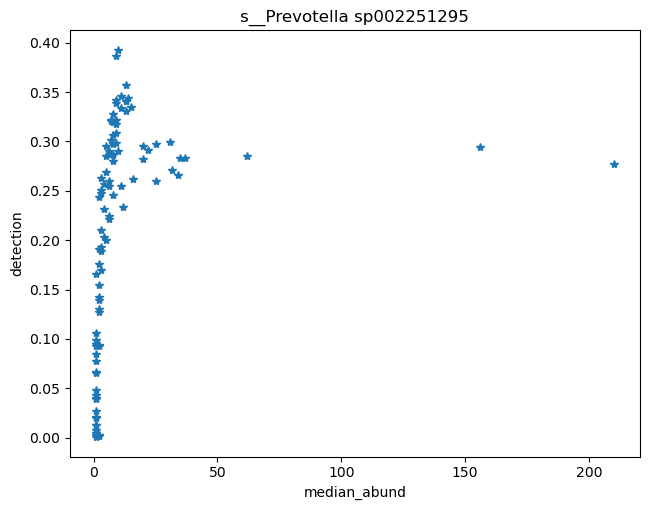

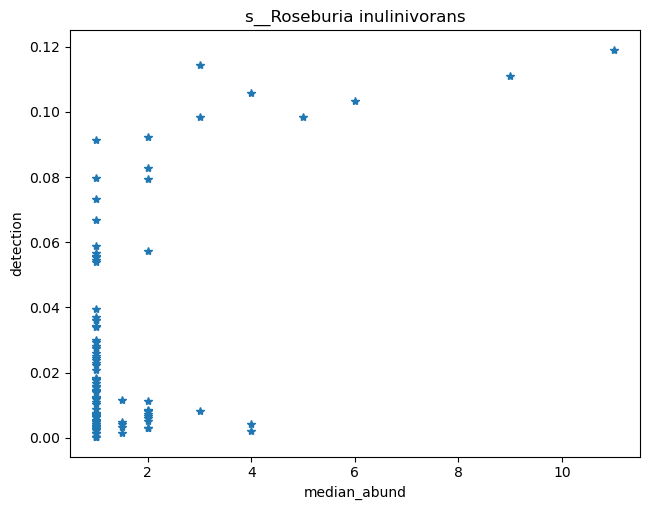

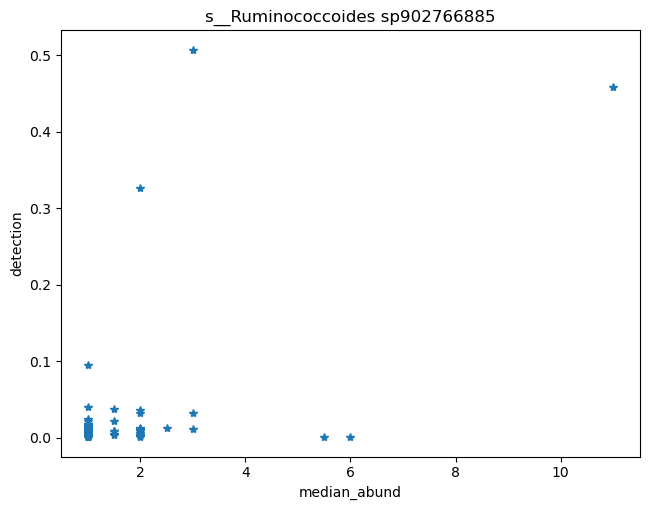

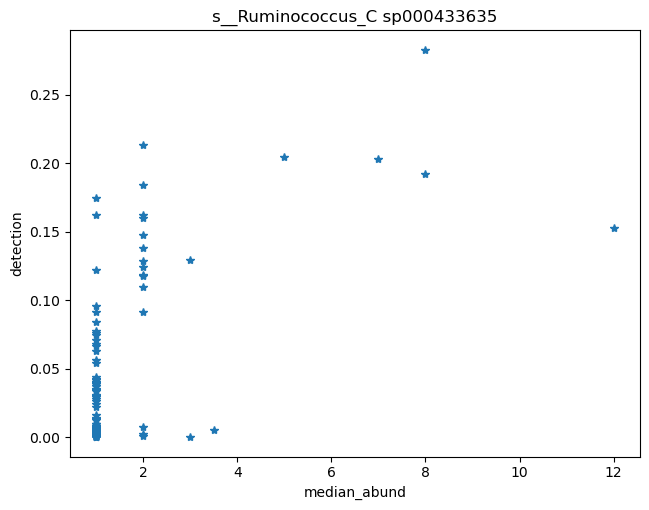

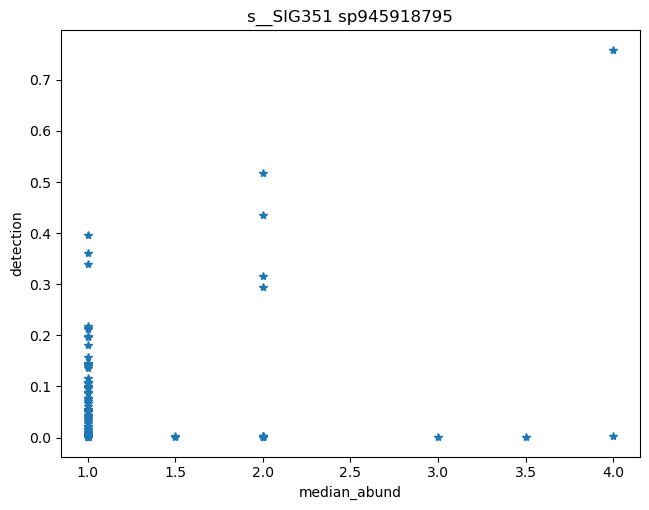

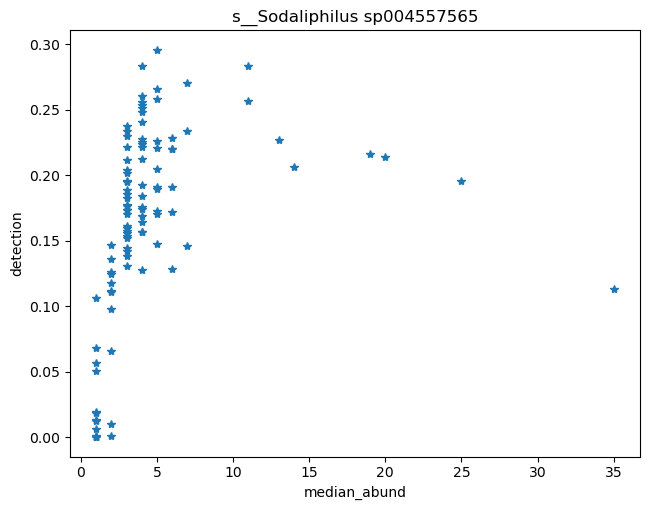

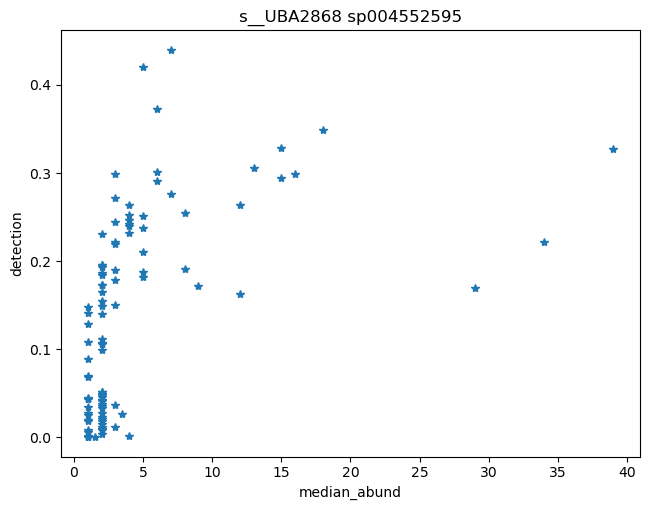

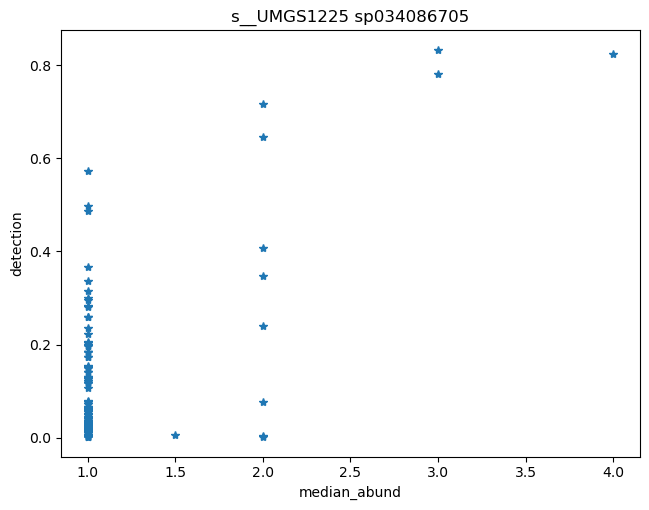

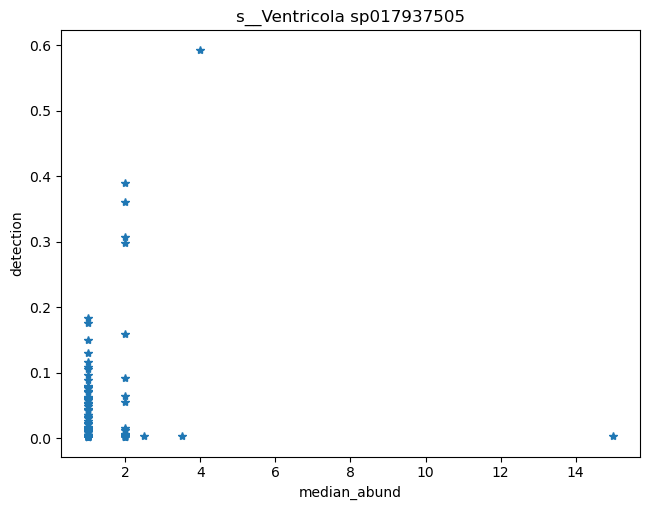

In [24]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)
    plt.plot(species_df['median_abund'], species_df['containment'], '*')
    plt.tight_layout()
    plt.title(name)
    plt.xlabel('median_abund')
    plt.ylabel('detection')
    plt.show()

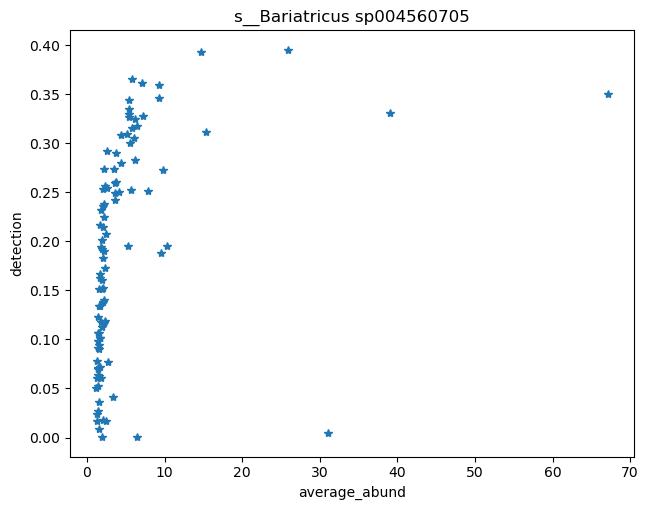

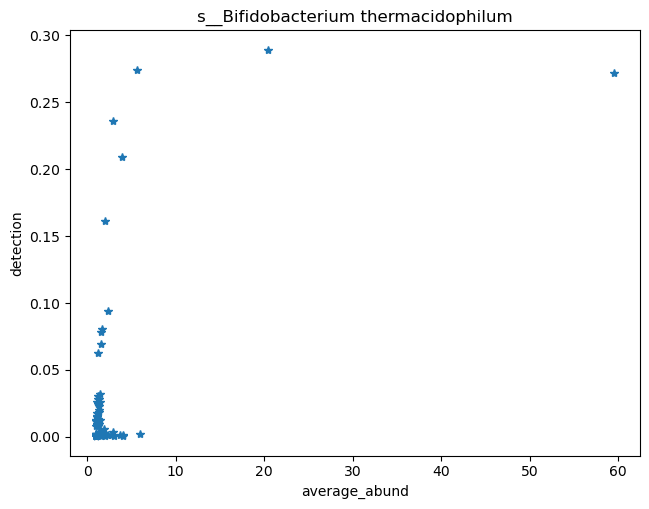

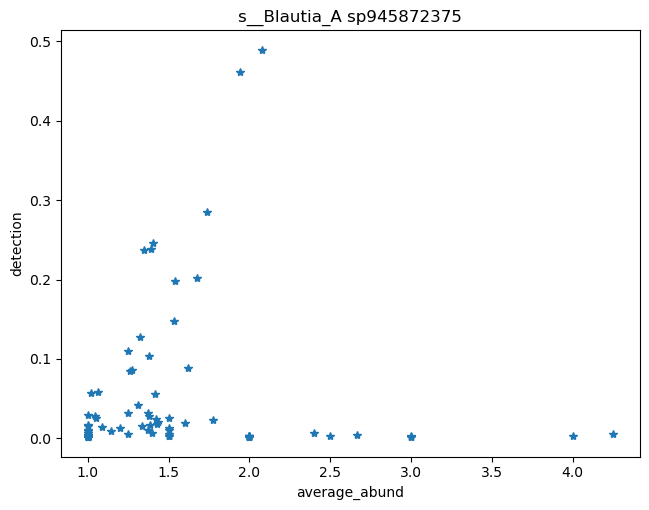

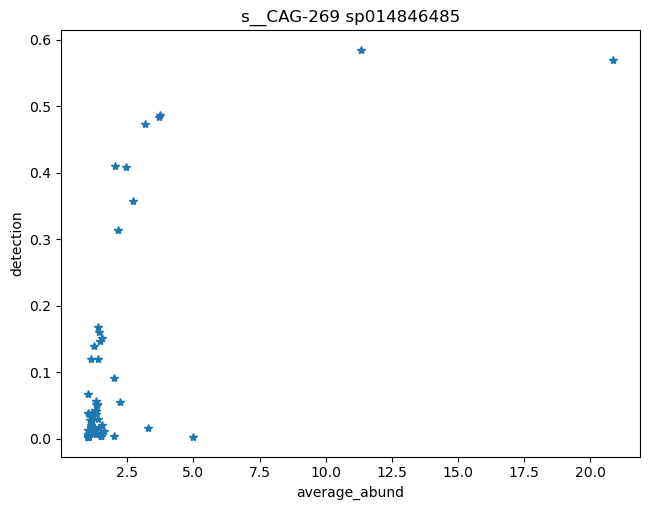

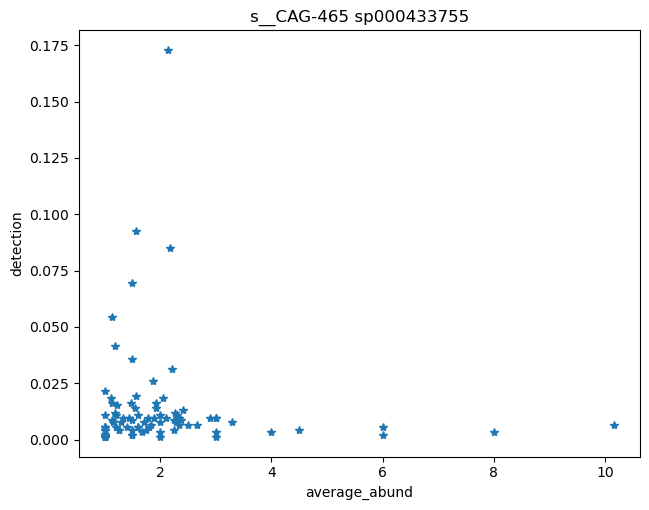

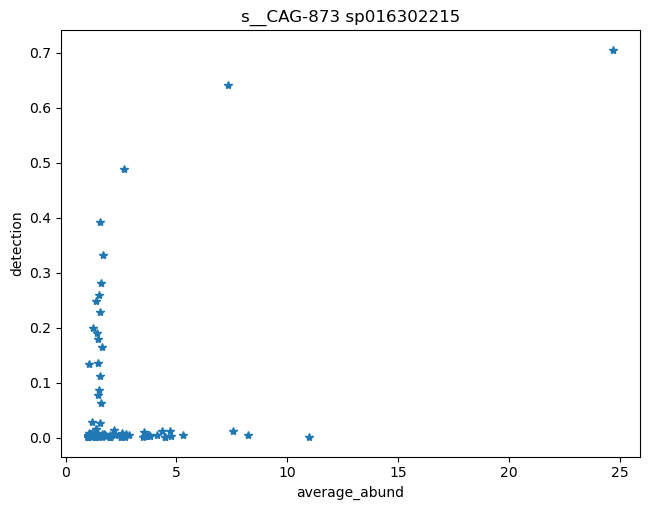

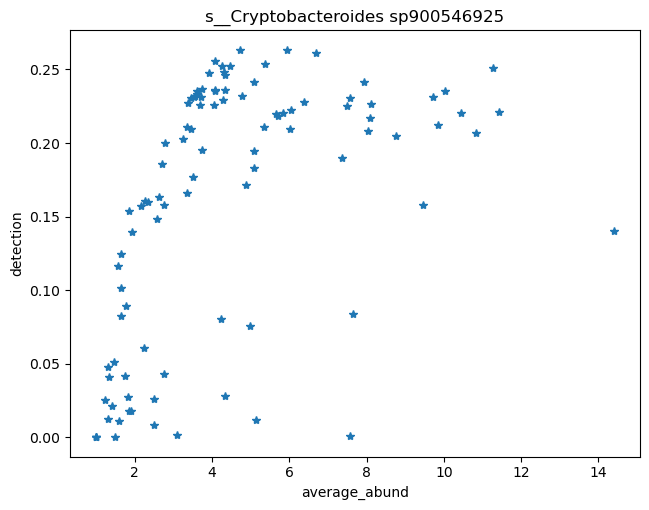

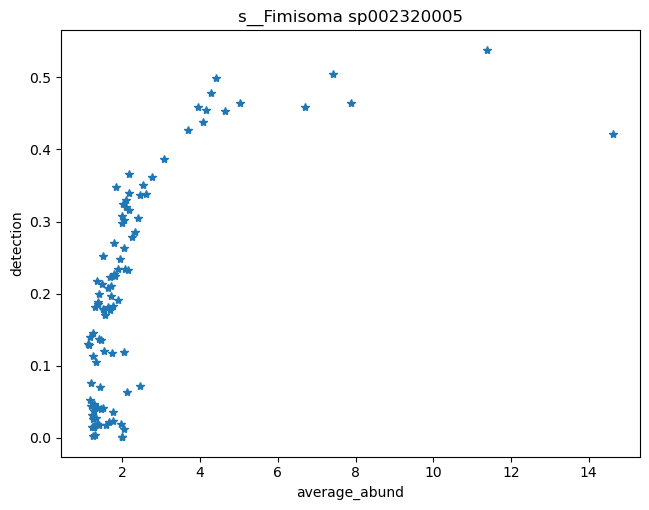

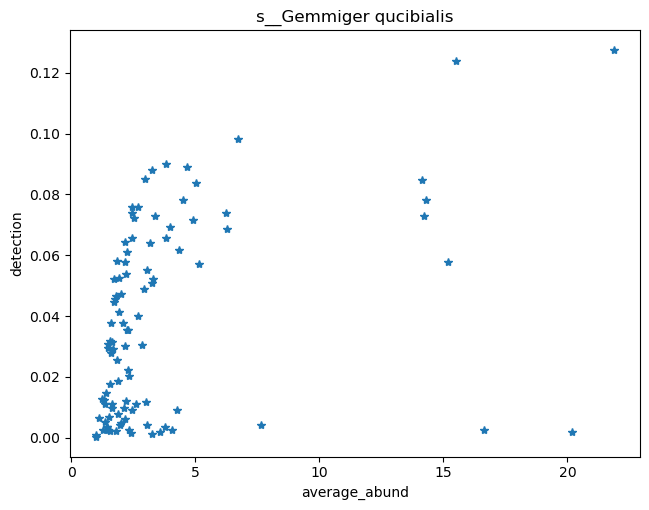

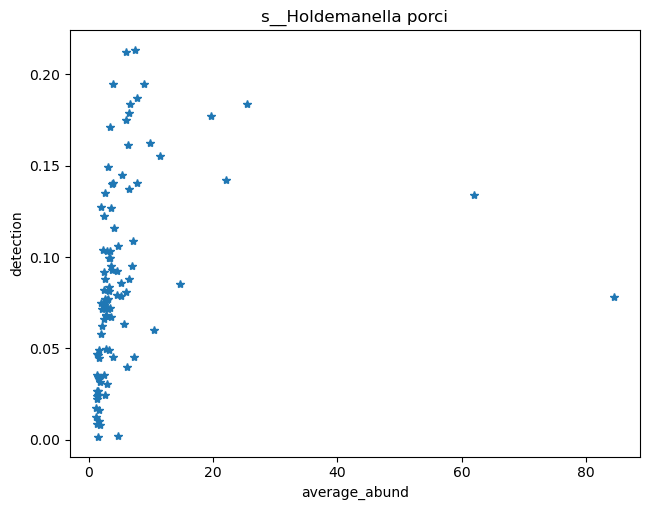

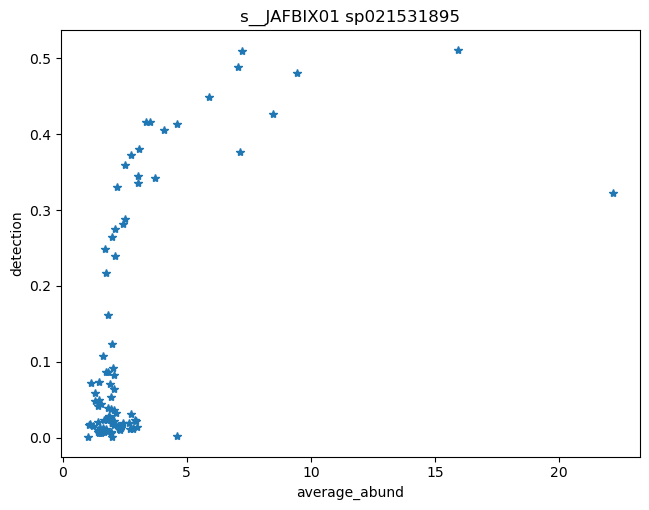

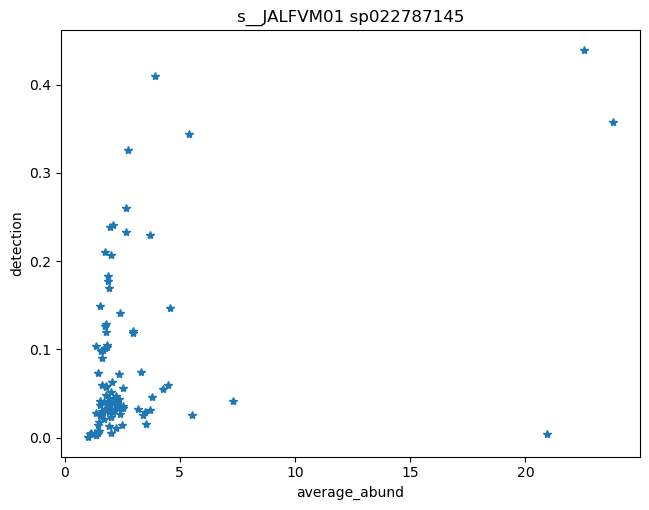

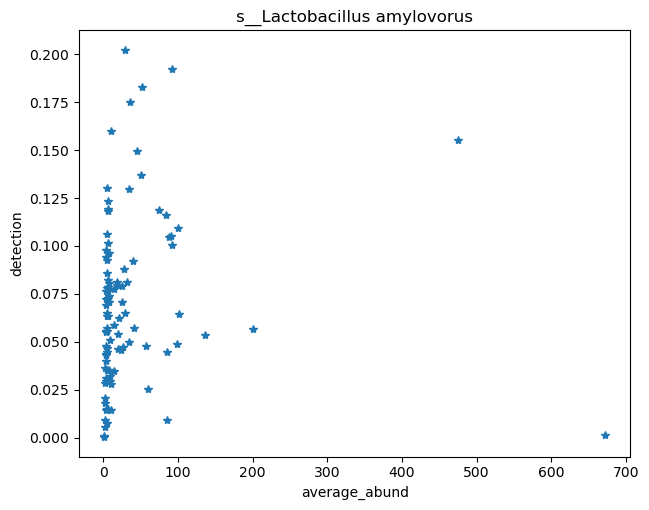

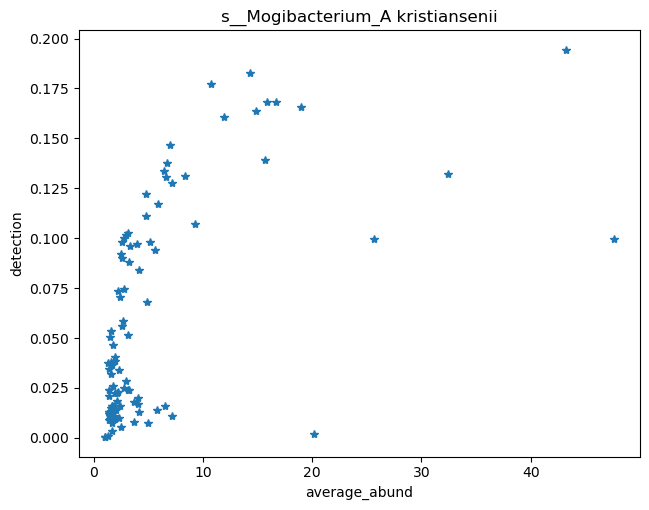

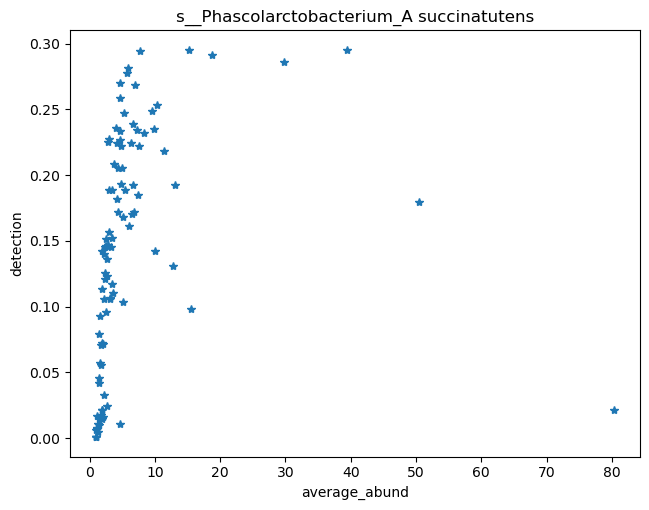

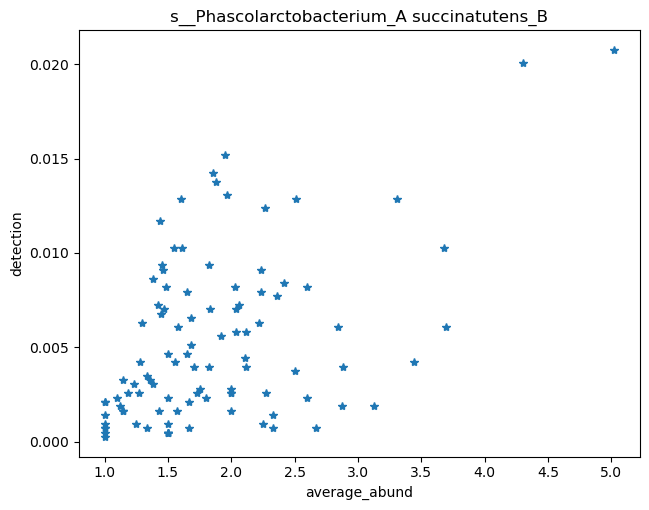

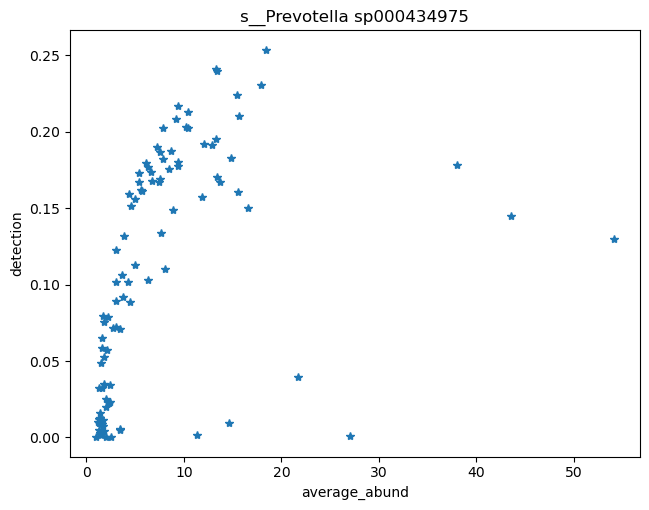

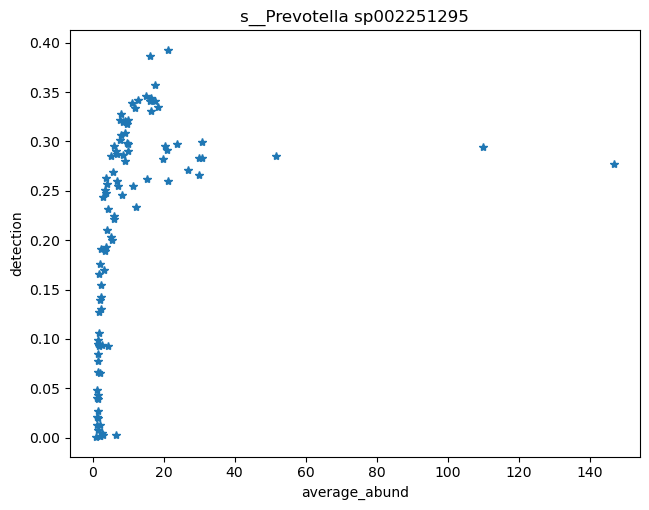

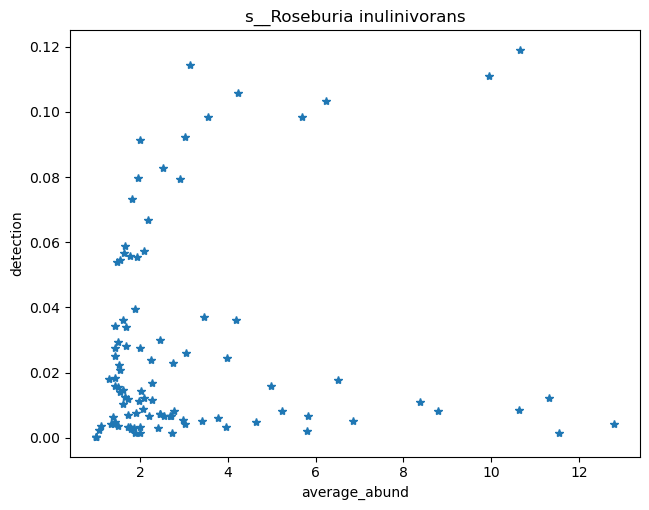

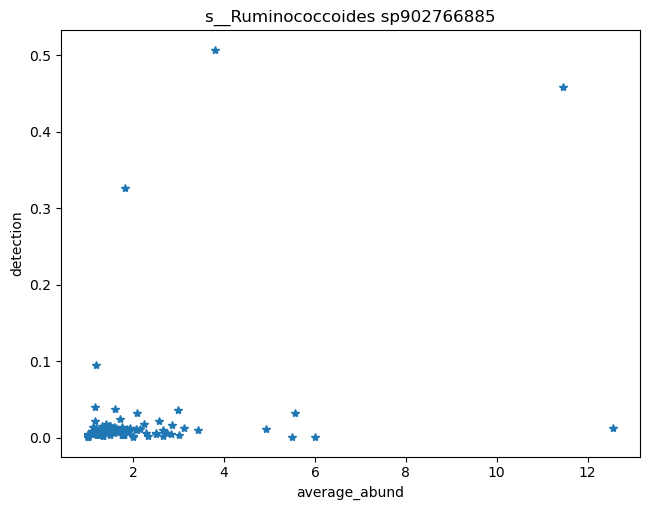

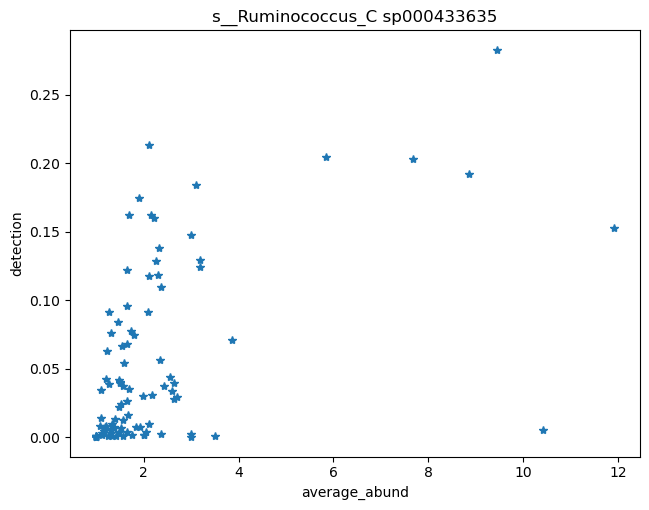

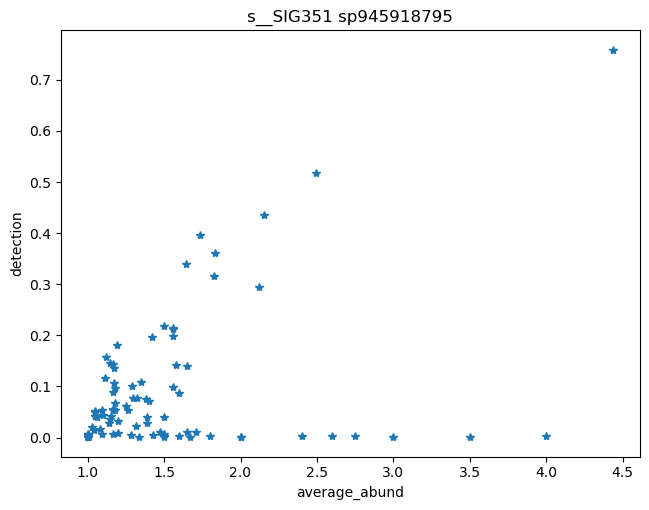

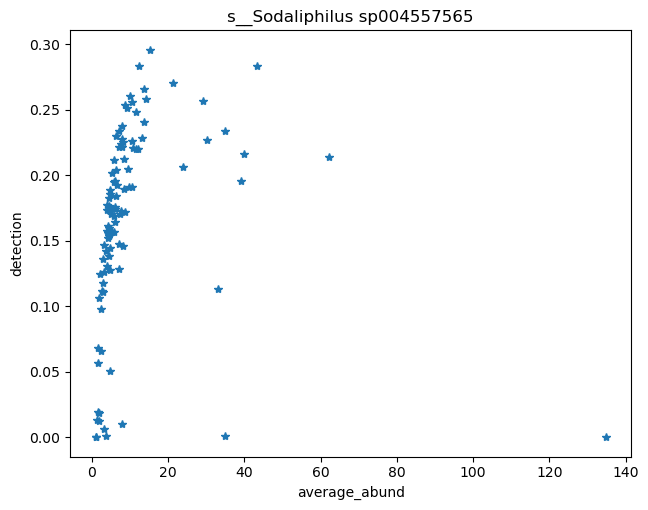

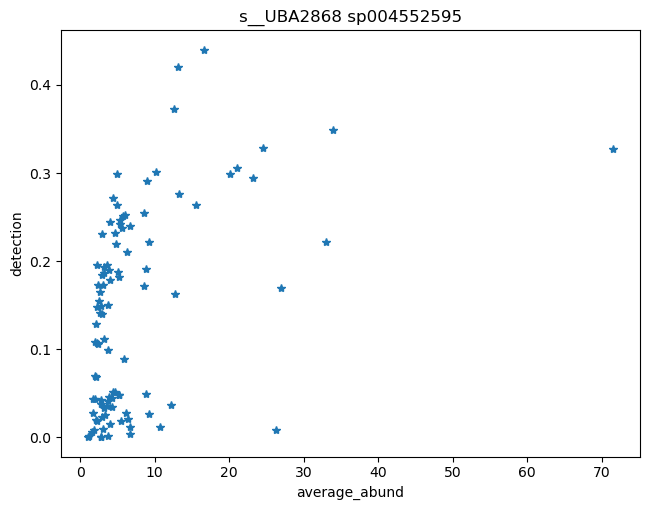

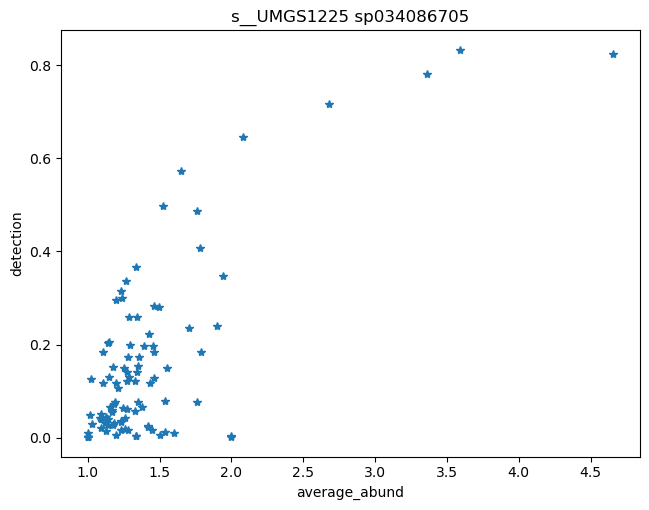

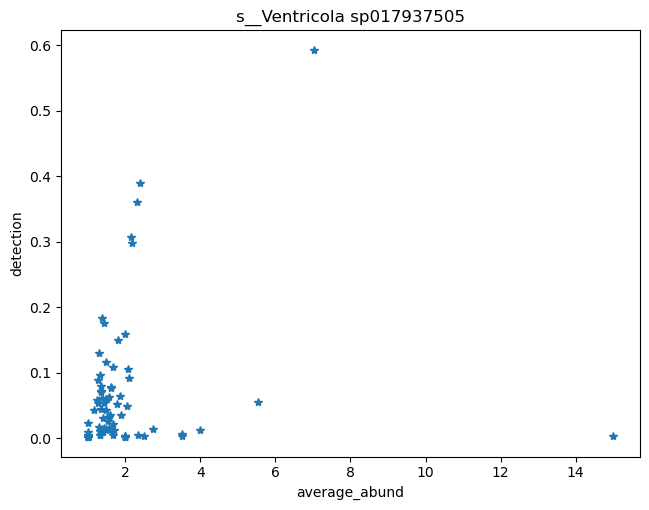

In [25]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)
    plt.plot(species_df['average_abund'], species_df['containment'], '*')
    plt.tight_layout()
    plt.title(name)
    plt.xlabel('average_abund')
    plt.ylabel('detection')
    plt.show()